In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [6]:
df_packers = pd.read_excel('../data/MODFLOW_layers_priors.xlsx')
df_packers.head()

,borehole,northing,easting,layer,Kh (m/day),source,notes
0,PW-1,4980066,480869,1,0.15638,"packer test (PEER, 1999)",NaN
1,PW-1,4980066,480869,2,9.15840,"packer test (PEER, 1999)",NaN
2,PW-1,4980066,480869,3,0.04208,"packer test (PEER, 1999)",NaN
3,PW-2,4980048,480794,1,17.62560,"packer test (PEER, 1999)",average between 15.984 and 19.2672
4,PW-2,4980048,480794,2,24.96960,"packer test (PEER, 1999)",NaN


Layer 1 data (packer data)

In [7]:
lyr1 = df_packers[df_packers['layer'] == 1]
lyr1

,borehole,northing,easting,layer,Kh (m/day),source,notes
0,PW-1,4980066,480869,1,0.15638,"packer test (PEER, 1999)",NaN
3,PW-2,4980048,480794,1,17.62560,"packer test (PEER, 1999)",average between 15.984 and 19.2672
6,PZ-2,4980037,480808,1,12.09600,"packer test (PEER, 1999)",does not seem accurate/reliable
9,94-02,4980038,480890,1,NaN,"packer test (CNA, 1997)",not tested
12,94-07,4980198,480782,1,NaN,"packer test (CNA, 1997)",not tested
15,94-08,4979864,480711,1,NaN,"packer test (CNA, 1997)",not tested
18,94-09,4979900,480919,1,NaN,"packer test (CNA, 1997)",not tested
21,94-10,4979932,480805,1,0.34311,"packer test (CNA, 1997)",NaN
24,94-11,4980004,480833,1,16.68270,"packer test (CNA, 1997)",NaN
27,94-16,4979933,480730,1,18.18656,"packer test (CNA, 1997)",NaN


In [8]:
lyr1['logK'] = np.log(lyr1['Kh (m/day)'])
lyr1

C:\Users\LIMA0055\AppData\Local\Temp\ipykernel_58532\3371934971.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lyr1['logK'] = np.log(lyr1['Kh (m/day)'])


,borehole,northing,easting,layer,Kh (m/day),source,notes,logK
0,PW-1,4980066,480869,1,0.15638,"packer test (PEER, 1999)",NaN,-1.855466
3,PW-2,4980048,480794,1,17.62560,"packer test (PEER, 1999)",average between 15.984 and 19.2672,2.869352
6,PZ-2,4980037,480808,1,12.09600,"packer test (PEER, 1999)",does not seem accurate/reliable,2.492875
9,94-02,4980038,480890,1,NaN,"packer test (CNA, 1997)",not tested,NaN
12,94-07,4980198,480782,1,NaN,"packer test (CNA, 1997)",not tested,NaN
15,94-08,4979864,480711,1,NaN,"packer test (CNA, 1997)",not tested,NaN
18,94-09,4979900,480919,1,NaN,"packer test (CNA, 1997)",not tested,NaN
21,94-10,4979932,480805,1,0.34311,"packer test (CNA, 1997)",NaN,-1.069704
24,94-11,4980004,480833,1,16.68270,"packer test (CNA, 1997)",NaN,2.814372
27,94-16,4979933,480730,1,18.18656,"packer test (CNA, 1997)",NaN,2.900683


<Axes: >

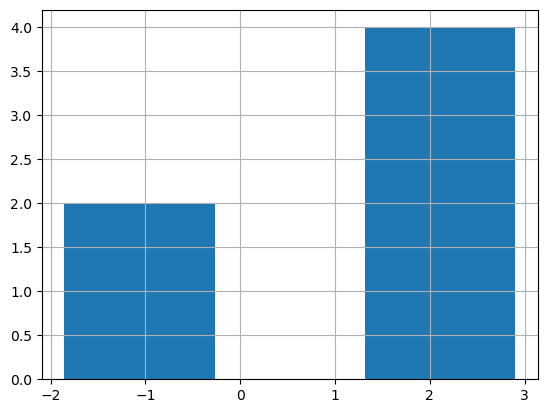

In [11]:
lyr1['logK'].hist(bins=3)

In [12]:
lyr1['logK'].describe()

count    6.000000
mean     1.358685
std      2.204229
min     -1.855466
25%     -0.179059
50%      2.653624
75%      2.855607
max      2.900683
Name: logK, dtype: float64

In [13]:
lyr1['Kh (m/day)'].describe()

count     6.000000
mean     10.848392
std       8.485930
min       0.156380
25%       3.281333
50%      14.389350
75%      17.389875
max      18.186560
Name: Kh (m/day), dtype: float64

Standanrd deviation of layer 1 prior information: 8.48 normal, 2.2 log transformed

prior parameter bounds for layer 1 will be based on: 

$$ \sigma = \frac{parubn - parlbnd}{4}$$

and weights:

$$ weight = \frac{1}{\sigma} $$

In [17]:
#computing parameter bounds
lyr1_par_bnd = 4*lyr1['Kh (m/day)'].std()
lyr1_par_bnd

33.943718308502774

doing the same for layer 3

In [38]:
lyr3 = df_packers[df_packers['layer'] == 3]
lyr3['logK'] = np.log(lyr3['Kh (m/day)'])
lyr3

C:\Users\LIMA0055\AppData\Local\Temp\ipykernel_58532\3191239024.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lyr3['logK'] = np.log(lyr3['Kh (m/day)'])


,borehole,northing,easting,layer,Kh (m/day),source,notes,logK
2,PW-1,4980066,480869,3,0.042080,"packer test (PEER, 1999)",NaN,-3.168183
5,PW-2,4980048,480794,3,NaN,"packer test (PEER, 1999)",not tested,NaN
8,PZ-2,4980037,480808,3,25.862400,"packer test (PEER, 1999)","average between (26.43840, 23.84640, 27.30240)",3.252790
11,94-02,4980038,480890,3,0.209863,"packer test (CNA, 1997)","average between (0.37042, 0.17790, 0.15445, 0....",-1.561303
14,94-07,4980198,480782,3,0.237867,"packer test (CNA, 1997)","average between (0.27337, 0.23365, 0.20658)",-1.436045
17,94-08,4979864,480711,3,0.288900,"packer test (CNA, 1997)","average between (0.30866, 0.42640, 0.13164)",-1.241675
20,94-09,4979900,480919,3,3.274515,"packer test (CNA, 1997)","average between (12.30757, 0.22225, 0.19762, 0...",1.186170
23,94-10,4979932,480805,3,0.149703,"packer test (CNA, 1997)","average between (0.16944, 0.14803, 0.13164)",-1.899100
26,94-11,4980004,480833,3,0.879843,"packer test (CNA, 1997)","average between (0.07402, 1.01561, 1.54990)",-0.128011
29,94-16,4979933,480730,3,0.458860,"packer test (CNA, 1997)","average between (1.51673, 0.11113, 0.10162, 0....",-0.779010


In [39]:
#dropping data from PZ-2, it is not reliable
lyr3 = lyr3.drop(8)
lyr3

,borehole,northing,easting,layer,Kh (m/day),source,notes,logK
2,PW-1,4980066,480869,3,0.042080,"packer test (PEER, 1999)",NaN,-3.168183
5,PW-2,4980048,480794,3,NaN,"packer test (PEER, 1999)",not tested,NaN
11,94-02,4980038,480890,3,0.209863,"packer test (CNA, 1997)","average between (0.37042, 0.17790, 0.15445, 0....",-1.561303
14,94-07,4980198,480782,3,0.237867,"packer test (CNA, 1997)","average between (0.27337, 0.23365, 0.20658)",-1.436045
17,94-08,4979864,480711,3,0.288900,"packer test (CNA, 1997)","average between (0.30866, 0.42640, 0.13164)",-1.241675
20,94-09,4979900,480919,3,3.274515,"packer test (CNA, 1997)","average between (12.30757, 0.22225, 0.19762, 0...",1.186170
23,94-10,4979932,480805,3,0.149703,"packer test (CNA, 1997)","average between (0.16944, 0.14803, 0.13164)",-1.899100
26,94-11,4980004,480833,3,0.879843,"packer test (CNA, 1997)","average between (0.07402, 1.01561, 1.54990)",-0.128011
29,94-16,4979933,480730,3,0.458860,"packer test (CNA, 1997)","average between (1.51673, 0.11113, 0.10162, 0....",-0.779010


<Axes: >

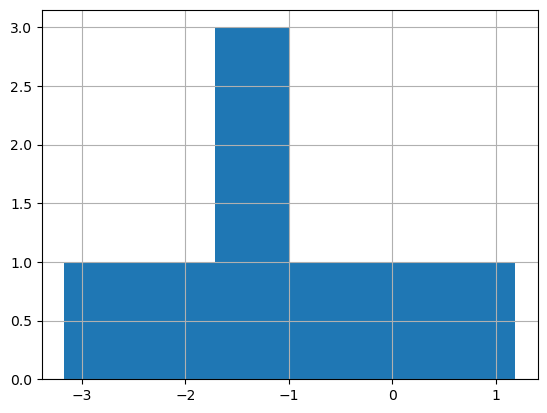

In [40]:
lyr3['logK'].hist(bins=6)

In [41]:
lyr3['logK'].describe()

count    8.000000
mean    -1.128395
std      1.283392
min     -3.168183
25%     -1.645752
50%     -1.338860
75%     -0.616260
max      1.186170
Name: logK, dtype: float64

In [42]:
lyr3['Kh (m/day)'].describe()

count    8.000000
mean     0.692704
std      1.074156
min      0.042080
25%      0.194823
50%      0.263383
75%      0.564106
max      3.274515
Name: Kh (m/day), dtype: float64

In [43]:
#computing parameter bounds
lyr3_par_bnd = 4*lyr3['Kh (m/day)'].std()
lyr3_par_bnd

4.296625675067288

computing for layer 2 (BPP) - before adding slug test data just to check std

In [26]:
lyr2 = df_packers[df_packers['layer'] == 2]
lyr2['logK'] = np.log(lyr2['Kh (m/day)'])
lyr2

C:\Users\LIMA0055\AppData\Local\Temp\ipykernel_58532\2956809674.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lyr2['logK'] = np.log(lyr2['Kh (m/day)'])


,borehole,northing,easting,layer,Kh (m/day),source,notes,logK
1,PW-1,4980066,480869,2,9.158400,"packer test (PEER, 1999)",NaN,2.214671
4,PW-2,4980048,480794,2,24.969600,"packer test (PEER, 1999)",NaN,3.217659
7,PZ-2,4980037,480808,2,5.624640,"packer test (PEER, 1999)",NaN,1.727157
10,94-02,4980038,480890,2,7.092215,"packer test (CNA, 1997)","average between (6.46046, 7.72397)",1.958998
13,94-07,4980198,480782,2,26.408272,"packer test (CNA, 1997)","average between (18.10218, 28.69549, 38.02080,...",3.273677
16,94-08,4979864,480711,2,30.443695,"packer test (CNA, 1997)","average between (24.31918, 36.56821)",3.415879
19,94-09,4979900,480919,2,23.326910,"packer test (CNA, 1997)",NaN,3.149608
22,94-10,4979932,480805,2,51.195490,"packer test (CNA, 1997)",NaN,3.935651
25,94-11,4980004,480833,2,16.897960,"packer test (CNA, 1997)",NaN,2.827193
28,94-16,4979933,480730,2,12.193260,"packer test (CNA, 1997)",NaN,2.500883


<Axes: >

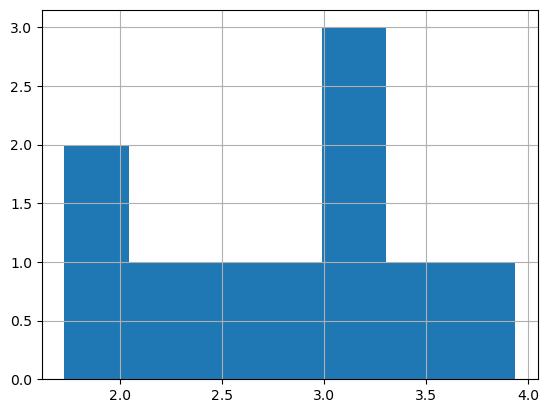

In [28]:
lyr2['logK'].hist(bins=7)

In [30]:
lyr2['logK'].describe()

count    10.000000
mean      2.822138
std       0.705238
min       1.727157
25%       2.286224
50%       2.988400
75%       3.259673
max       3.935651
Name: logK, dtype: float64

In [31]:
lyr2['Kh (m/day)'].describe()

count    10.000000
mean     20.731044
std      13.804534
min       5.624640
25%       9.917115
50%      20.112435
75%      26.048604
max      51.195490
Name: Kh (m/day), dtype: float64

In [32]:
#computing parameter bounds
lyr2_par_bnd = 4*lyr2['Kh (m/day)'].std()
lyr2_par_bnd

55.21813448119981